# US Airport Network — Spectral Clustering Benchmark

**COMP702 Dissertation · Milestone 2**

Second in the dataset series (after `01_synthetic.ipynb`): the same five
algorithms and conventions, now on a **real-world network with no ground truth**.
With no labels, cluster quality is judged by *internal* indices (Silhouette,
Davies-Bouldin) under three embeddings, exactly as implemented in
`scripts/network_eval.py` and already run for all three network datasets.

| Algorithm | Reference |
|---|---|
| K-Means (baseline) | Lloyd (1957) |
| Unnormalised Spectral Clustering | von Luxburg (2007) |
| Normalised SC — Shi & Malik | Shi & Malik (2000) |
| Normalised SC — Ng, Jordan & Weiss | Ng, Jordan & Weiss (2001) |
| Self-Tuning SC — Zelnik-Manor & Perona | Zelnik-Manor & Perona (2004) |

A graph has no raw feature space, so the **K-Means baseline and Self-Tuning SC
operate on the unnormalised-Laplacian node embedding**, while the three
graph-native spectral methods operate on the **adjacency** directly. This is the
same setup used across the network datasets, and it is central to the fit-space
discussion in Section 6.

In [1]:
import sys
from pathlib import Path

# make the repo root importable whether launched from notebooks/ or the root
_here = Path.cwd()
_repo = _here if (_here / "scripts").exists() else _here.parent
sys.path.insert(0, str(_repo))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts import SEED
from scripts.network_datasets import load_airports
from scripts.selection import select_spectral_k
from scripts.spectral import (kmeans_baseline, unnormalised_spectral, spectral_shi_malik,
                              spectral_ng_jordan_weiss, self_tuning_spectral)
from scripts.network_eval import (build_embeddings, evaluate_multi_embedding,
                                  ranking_consistency, consistency_verdict,
                                  format_comparison_table, EMBEDDINGS)

np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 110
print(f"Global seed = {SEED}")

Global seed = 42


## 1. Setup and data loading

Each **node** is a US airport; each undirected **edge** joins two airports that
have at least one direct flight between them, **weighted by the total number of
flights** over the dataset period. The graph was aggregated from the raw Kaggle
flight-level records (`Airports2.csv`, ~510 MB) into `data/airports_graph.csv`
and is loaded here via `scripts.network_datasets.load_airports()`; we work with
its **largest connected component** so that shortest paths are finite and the
Laplacian spectrum is well behaved.

In [2]:
A, nodes, G = load_airports()
n_nodes, n_edges = A.shape[0], int(A.nnz // 2)
print(f"US Airport Network: {n_nodes} nodes, {n_edges} edges (largest connected component)")
print(f"Edge weight = total flights between the pair; example airport codes: {nodes[:12]}")

US Airport Network: 727 nodes, 22955 edges (largest connected component)
Edge weight = total flights between the pair; example airport codes: ['AMW', 'MHK', 'EUG', 'RDM', 'MFR', 'SEA', 'PDX', 'LMT', 'SFO', 'LAX', 'EAT', 'YKM']


## 2. Graph structure overview

Before clustering, a quick look at the **degree distribution** — how many other
airports each airport connects to. Air-transport networks are famously
**hub-and-spoke**, so we expect a heavy right tail: a few large hubs with very
high degree and many small regional airports with low degree.

**Why this matters for the algorithms.** On a hub-heavy network the node degrees
span a wide range, and the way each method treats degree becomes decisive. The
*unnormalised* Laplacian ($L = D - W$) is dominated by high-degree hubs, so it
tends to peel off a single extreme node; the *normalised* methods (Shi & Malik's
$D^{-1}L$ and Ng-Jordan-Weiss's $D^{-1/2} L D^{-1/2}$) rescale by degree and are
far better suited to graphs with such uneven degrees. We should expect degree
normalisation to matter a lot here.

Unweighted degree: min=1, median=24, mean=63.1, max=376  (mean >> median => heavy right tail)
Top-10 hub airports by number of connections:
   YIP  degree=376  total_flights=21,638
   MSP  degree=319  total_flights=6,404,123
   MCI  degree=317  total_flights=2,575,336
   MEM  degree=315  total_flights=3,583,105
   ATL  degree=305  total_flights=13,102,590
   STL  degree=302  total_flights=6,358,611
   MIA  degree=297  total_flights=2,968,589
   ORD  degree=296  total_flights=13,804,469
   DFW  degree=295  total_flights=11,982,188
   IND  degree=294  total_flights=2,112,706
The busiest 5% of airports account for 21% of all connections.


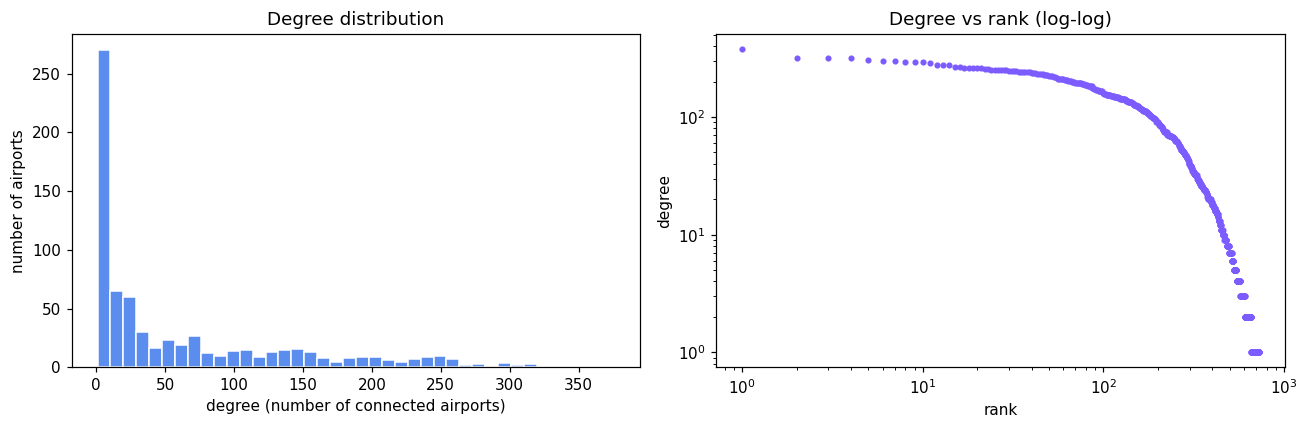

In [3]:
deg = np.array([d for _, d in G.degree()])
strength = np.array([s for _, s in G.degree(weight="weight")])  # total flights per airport
order = np.argsort(-deg)

print(f"Unweighted degree: min={deg.min()}, median={np.median(deg):.0f}, "
      f"mean={deg.mean():.1f}, max={deg.max()}  (mean >> median => heavy right tail)")
print("Top-10 hub airports by number of connections:")
for i in order[:10]:
    print(f"   {nodes[i]:4s} degree={int(deg[i]):3d}  total_flights={int(strength[i]):,}")
share = 100 * deg[order[:max(1, n_nodes // 20)]].sum() / deg.sum()
print(f"The busiest 5% of airports account for {share:.0f}% of all connections.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(deg, bins=40, color="#5b8def", edgecolor="white")
axes[0].set_title("Degree distribution")
axes[0].set_xlabel("degree (number of connected airports)")
axes[0].set_ylabel("number of airports")
axes[1].loglog(np.arange(1, n_nodes + 1), deg[order], "o", ms=3, color="#7c5cff")
axes[1].set_title("Degree vs rank (log-log)")
axes[1].set_xlabel("rank"); axes[1].set_ylabel("degree")
plt.tight_layout(); plt.show()

## 3. Choosing *k*

We reuse the notebook series' **two-step spectral k-selection**
(`select_spectral_k`): shortlist candidate *k* from the eigenvalue gaps
(`suggest_k_candidates`), then disambiguate by clustering quality
(`pick_best_k`). There is **no ground truth here**, so the disambiguation
criterion is the **Silhouette Score** (on the synthetic data we validated that
Silhouette is reliable for convex structure — Section 3b/8 of `01_synthetic.ipynb`
— but should be read with care otherwise). The candidate reference clustering is
Ng-Jordan-Weiss on the adjacency, matching the network evaluation pipeline. The
value of *k* is **derived here, not hardcoded**.

candidates = [2, 6, 5]  ->  two-step k = 2 (silhouette disambiguation)
Silhouette per candidate: {2: -0.039, 6: -0.861, 5: -0.824}


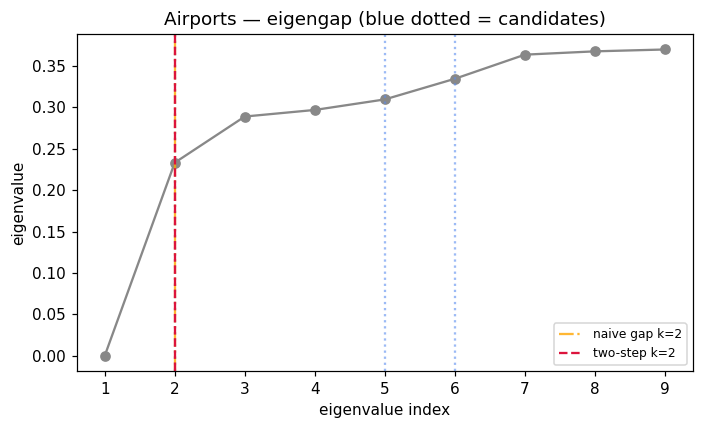

In [4]:
# the three embeddings are built once and reused in Section 5
embeddings, timings = build_embeddings(A, n_components=10)
X_embed = embeddings["unnorm"]     # graphs have no raw features; use the node embedding
A_dense = A.toarray()

spectral_sel = select_spectral_k(
    A_dense, X_embed,
    reference_fn=lambda kk: spectral_ng_jordan_weiss(A_dense, kk),
    ground_truth=None, top_n=3, k_min=2, k_max=8,
)
k = spectral_sel["best_k"]
print(f"candidates = {spectral_sel['candidates']}  ->  two-step k = {k} "
      f"({spectral_sel['criterion']} disambiguation)")
print(f"Silhouette per candidate: "
      f"{ {kk: round(v, 3) for kk, v in spectral_sel['scores'].items()} }")

ev = spectral_sel["eigenvalues"]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(range(1, len(ev) + 1), ev, "o-", color="#888")
for c in spectral_sel["candidates"]:
    ax.axvline(c, color="#5b8def", ls=":", alpha=0.6)
ax.axvline(spectral_sel["naive_suggested_k"], color="orange", ls="-.", alpha=0.8,
           label=f'naive gap k={spectral_sel["naive_suggested_k"]}')
ax.axvline(k, color="crimson", ls="--", label=f'two-step k={k}')
ax.set_title("Airports — eigengap (blue dotted = candidates)")
ax.set_xlabel("eigenvalue index"); ax.set_ylabel("eigenvalue")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Run all five algorithms

Same fixed seed and `n_init=10` convention as the synthetic notebook (baked into
`scripts.spectral`). The graph-native spectral methods take the adjacency; the
K-Means baseline and Self-Tuning SC take the unnormalised-Laplacian embedding.

In [5]:
algorithms = {
    "K-Means (embedding)":         lambda kk: kmeans_baseline(X_embed, kk),
    "Unnormalised SC":             lambda kk: unnormalised_spectral(A_dense, kk),
    "Shi-Malik SC":                lambda kk: spectral_shi_malik(A_dense, kk),
    "Ng-Jordan-Weiss SC":          lambda kk: spectral_ng_jordan_weiss(A_dense, kk),
    "Self-Tuning SC (embedding)":  lambda kk: self_tuning_spectral(X_embed, kk),
}
labels = {name: np.asarray(fn(k)) for name, fn in algorithms.items()}
for name, lab in labels.items():
    sizes = sorted(np.bincount(lab).tolist(), reverse=True)
    print(f"{name:28s} cluster sizes = {sizes}")

K-Means (embedding)          cluster sizes = [726, 1]
Unnormalised SC              cluster sizes = [726, 1]
Shi-Malik SC                 cluster sizes = [589, 138]
Ng-Jordan-Weiss SC           cluster sizes = [539, 188]
Self-Tuning SC (embedding)   cluster sizes = [701, 26]


## 4b. Diagnostic — which airport is isolated, and why?

Section 4 showed that K-Means (on the unnormalised embedding) and Unnormalised SC
both return a degenerate $[726, 1]$ split. In the style of the synthetic
notebook's Section 9 diagnostic, this short section identifies the single isolated
airport and explains *structurally* why the unnormalised embedding singles it out
while the degree-normalised methods do not.

In [6]:
import networkx as nx

deg = np.array([d for _, d in G.degree()])
strength = np.array([s for _, s in G.degree(weight="weight")])
mu = X_embed.mean(axis=0)
dcen = np.linalg.norm(X_embed - mu, axis=1)

def singleton_codes(lab):
    vals, cnts = np.unique(lab, return_counts=True)
    idx = np.where(lab == vals[cnts.argmin()])[0]
    return [nodes[i] for i in idx], idx

# (1) identify the isolated airport for both methods
for name in ["K-Means (embedding)", "Unnormalised SC"]:
    codes, _ = singleton_codes(labels[name])
    print(f"{name:20s} smallest cluster = {codes}")
codes, idx = singleton_codes(labels["K-Means (embedding)"])
ai = idx[0]; code = nodes[ai]
print(f"\n=> isolated airport: {code}  (identical under both methods)")

# (2) degree / strength vs the Section-2 distribution
nbrs = sorted(((c, int(v["weight"])) for c, v in G[code].items()), key=lambda t: -t[1])
print("\n[structure]")
print(f"  degree            = {int(deg[ai])}   (median {np.median(deg):.0f}, mean {deg.mean():.1f}, "
      f"range {deg.min()}-{deg.max()})  -> {100*(deg < deg[ai]).mean():.0f}th percentile")
print(f"  strength (flights)= {int(strength[ai])}   (median {np.median(strength):.0f}, "
      f"mean {strength.mean():.0f})  -> {100*(strength < strength[ai]).mean():.0f}th percentile")
print(f"  only neighbour(s) = {nbrs}")

# (3) how extreme is it in the unnormalised embedding?
print("\n[embedding]  distance to the embedding centroid")
print(f"  {code} = {dcen[ai]:.4f}   typical (median) = {np.median(dcen):.4f}   "
      f"mean = {dcen.mean():.4f}   max = {dcen.max():.4f}")
print(f"  -> {dcen[ai]/np.median(dcen):.0f}x the median distance; "
      f"rank {int((dcen > dcen[ai]).sum())} of {len(nodes)} (0 = most extreme)")
print(f"  leading eigenvector coordinate = {X_embed[ai, 0]:.4f}  "
      f"(largest |value| of all {len(nodes)} airports on that axis)")

# (4) structural role: articulation point?
arts = set(nx.articulation_points(G))
H = G.copy(); H.remove_node(code)
comps = sorted((len(c) for c in nx.connected_components(H)), reverse=True)
print("\n[topology]")
print(f"  articulation point (cut vertex)? {code in arts}")
print(f"  removing {code} -> {len(comps)} component(s), sizes {comps[:3]}  "
      f"=> it is a pendant (degree-1) leaf, not a cut vertex")

# (5) where do the normalised methods place it?
print("\n[normalised methods]")
for name in ["Shi-Malik SC", "Ng-Jordan-Weiss SC"]:
    lab = labels[name]; sizes = sorted(np.bincount(lab).tolist(), reverse=True)
    own = int((lab == lab[ai]).sum())
    print(f"  {name:20s}: {code} joins the {'larger' if own == max(sizes) else 'smaller'} "
          f"cluster (size {own} of {sizes})")

K-Means (embedding)  smallest cluster = ['TVI']
Unnormalised SC      smallest cluster = ['TVI']

=> isolated airport: TVI  (identical under both methods)

[structure]
  degree            = 1   (median 24, mean 63.1, range 1-376)  -> 0th percentile
  strength (flights)= 1   (median 5342, mean 369239)  -> 0th percentile
  only neighbour(s) = [('CSV', 1)]

[embedding]  distance to the embedding centroid
  TVI = 0.9945   typical (median) = 0.0007   mean = 0.0199   max = 0.9945
  -> 1389x the median distance; rank 0 of 727 (0 = most extreme)
  leading eigenvector coordinate = -0.9944  (largest |value| of all 727 airports on that axis)

[topology]
  articulation point (cut vertex)? False
  removing TVI -> 1 component(s), sizes [726]  => it is a pendant (degree-1) leaf, not a cut vertex

[normalised methods]
  Shi-Malik SC        : TVI joins the larger cluster (size 589 of [589, 138])
  Ng-Jordan-Weiss SC  : TVI joins the larger cluster (size 539 of [539, 188])


### Conclusion

The isolated airport is **TVI** (Thomasville, GA), and it is the same one for both
methods. It is the network's most **weakly-connected** node: **degree 1** — its
lone route, to CSV, carries a **single flight** — against a dataset median degree
of 24 and mean of 63 (0th percentile on both degree and flight volume). It is a
**pendant leaf, not a cut vertex**: removing it leaves the graph fully connected.

**Why the unnormalised embedding isolates it.** The unnormalised Laplacian
$L = D - W$ has low-lying eigenvectors that *localise* on very low-degree nodes.
For TVI this is extreme: its distance from the embedding centroid is **0.994 —
roughly 1,400x the median (0.0007) and the single largest of all 727 airports** —
and the leading non-trivial eigenvector is effectively a "TVI vs everyone else"
indicator (TVI $\approx -0.994$, every other airport $\approx 0$). One whole axis
of `X_embed` therefore *is* "is this TVI?", so K-Means trivially cleaves that one
point off from the other 726 — the $[726, 1]$ split that internal indices then
reward in the unnormalised embedding (Section 6).

**Why the degree-normalised methods don't.** Shi-Malik ($D^{-1}L$) and
Ng-Jordan-Weiss ($D^{-1/2} L D^{-1/2}$, with a row-normalised embedding) rescale by
degree, which is exactly what neutralises a low-degree outlier: measured as a
*normalised cut*, snipping off a single degree-1 leaf is not a good partition once
cluster volume is accounted for. Consistent with that, both place TVI in the
**large** cluster (Shi-Malik size 589, Ng-Jordan-Weiss size 539) rather than
alone. This is the airport counterpart of the synthetic Section 9 finding: it is
the unnormalised embedding's *geometry* — not the clustering's quality — that
drives the degenerate result, and degree normalisation is what fixes it on a
hub-and-spoke network.

## 5. Evaluation under three embeddings

Silhouette and Davies-Bouldin for every algorithm under the **unnormalised
Laplacian**, **symmetric normalised Laplacian**, and **shortest-path (MDS)**
embeddings — the same neutral spaces used for every network dataset
(`evaluate_multi_embedding`). These results were already computed by the
benchmark, so we **load `results/network_eval_airports.json`** and display it,
recomputing only if the *k* derived in Section 3 differs from the stored run
(k = 2).

In [7]:
res_path = _repo / "results" / "network_eval_airports.json"
if k == 2 and res_path.exists():
    stored = json.load(open(res_path))
    print(f"Loaded precomputed results from {res_path.name} (k = {stored['k']}, "
          f"shortest-path timing {stored.get('shortest_path_seconds')} s).")
    df = pd.DataFrame(stored["table"])
else:
    print(f"Derived k = {k} differs from the stored run; recomputing.")
    df, _t = evaluate_multi_embedding(A, labels, n_components=10)
    stored = None

print("\nSilhouette Score by embedding (higher is better):")
print(format_comparison_table(df, "silhouette").to_string(index=False))
print("\nDavies-Bouldin Index by embedding (lower is better):")
print(format_comparison_table(df, "davies_bouldin").to_string(index=False))

for metric in ("silhouette", "davies_bouldin"):
    cons = ranking_consistency(df, metric=metric)
    print("\n" + consistency_verdict(cons, "airports"))
    print(f"  Spearman(rank) between embeddings: "
          f"{ {kk: round(v, 2) for kk, v in cons['spearman'].items()} }")

Loaded precomputed results from network_eval_airports.json (k = 2, shortest-path timing 0.225 s).

Silhouette Score by embedding (higher is better):
                 algorithm  silhouette_unnorm  silhouette_sym  silhouette_shortest_path
       K-Means (embedding)             0.9667         -0.7267                    0.2712
           Unnormalised SC             0.9667         -0.7267                    0.2712
              Shi-Malik SC             0.1511          0.4209                    0.1788
        Ng-Jordan-Weiss SC            -0.0392          0.3133                    0.1670
Self-Tuning SC (embedding)             0.8171         -0.6596                    0.0549

Davies-Bouldin Index by embedding (lower is better):
                 algorithm  davies_bouldin_unnorm  davies_bouldin_sym  davies_bouldin_shortest_path
       K-Means (embedding)                 0.0187              6.2690                        0.5644
           Unnormalised SC                 0.0187              6.2690

### Weighted modularity — an independent structural check

Following the Yeast notebook, we add **modularity** as a validation fully
independent of the embedding-based indices. The airport graph is weighted by
flight counts, so we use **weighted modularity** (flight-count edge weights),
consistent with how the similarity graph itself was constructed — in contrast to
Yeast PPI, whose binary interaction edges call for *unweighted* modularity, since
the two datasets have structurally different edge semantics.

In [8]:
from networkx.algorithms.community import modularity

def weighted_Q(lab, graph, node_list):
    pos = {nd: i for i, nd in enumerate(node_list)}
    comms = {}
    for nd in graph.nodes():
        comms.setdefault(int(lab[pos[nd]]), set()).add(nd)
    return modularity(graph, list(comms.values()), weight='weight')

print('Weighted modularity Q (flight-count weights; higher = denser weighted communities):')
Q_airports = {name: weighted_Q(lab, G, nodes) for name, lab in labels.items()}
for name, q in sorted(Q_airports.items(), key=lambda t: -t[1]):
    sizes = sorted(np.bincount(labels[name]).tolist(), reverse=True)
    print(f'  {name:28s} Q = {q:+.3f}   sizes = {sizes}')

Weighted modularity Q (flight-count weights; higher = denser weighted communities):


  Ng-Jordan-Weiss SC           Q = +0.223   sizes = [539, 188]
  Shi-Malik SC                 Q = +0.136   sizes = [589, 138]
  K-Means (embedding)          Q = -0.000   sizes = [726, 1]
  Unnormalised SC              Q = -0.000   sizes = [726, 1]
  Self-Tuning SC (embedding)   Q = -0.000   sizes = [701, 26]


The result confirms the degree-normalisation story from every other
angle. **Ng-Jordan-Weiss (Q ≈ +0.22)** and **Shi-Malik (Q ≈ +0.14)** carve out
genuinely dense weighted communities — the East/West geographic split of Section 8
— whereas **K-Means, Unnormalised SC and Self-Tuning all sit at Q ≈ 0** (no
community structure better than random), exactly as their degenerate $[726, 1]$
and imbalanced $[701, 26]$ splits imply. Geography, the three-embedding metrics,
*and* weighted modularity now all point to the same two winners.

## 6. Consistency and circularity

In [9]:
sil = df.set_index("algorithm")
km = sil.loc["K-Means (embedding)"]
print("Fit-space circularity — K-Means Silhouette across embeddings:")
print(f"   unnormalised = {km['silhouette_unnorm']:+.3f}   "
      f"symmetric = {km['silhouette_sym']:+.3f}   "
      f"shortest-path = {km['silhouette_shortest_path']:+.3f}")
csil = ranking_consistency(df, "silhouette")
print(f"\nSilhouette winner per embedding: {csil['winners']}")
print(f"Silhouette rank correlation unnorm~sym = "
      f"{csil['spearman']['unnorm~sym']:+.2f}")

Fit-space circularity — K-Means Silhouette across embeddings:
   unnormalised = +0.967   symmetric = -0.727   shortest-path = +0.271

Silhouette winner per embedding: {'unnorm': 'K-Means (embedding)', 'sym': 'Shi-Malik SC', 'shortest_path': 'K-Means (embedding)'}
Silhouette rank correlation unnorm~sym = -0.80


### Why the ranking is unstable here

The Silhouette ranking is **strongly embedding-dependent** — the best algorithm
changes with the embedding and the unnormalised and symmetric embeddings are
*anti-correlated* (Spearman $\approx -0.8$). The clearest symptom is the
**fit-space circularity**: K-Means and Self-Tuning are *fitted on* the
unnormalised-Laplacian embedding, so scoring them in that same space is
circular — K-Means scores an almost-perfect **Silhouette $\approx 0.97$ under the
unnormalised embedding but $\approx -0.73$ under the symmetric one**.

Section 4 makes the mechanism concrete: on this hub-heavy graph the unnormalised
methods (K-Means on the embedding, and Unnormalised SC) return a **degenerate
split that isolates essentially one airport** (cluster sizes $\approx [726, 1]$).
Internal indices *reward* such a split in the space it was produced in — a lone,
maximally-separated point inflates Silhouette and deflates Davies-Bouldin — even
though it is not a meaningful partition. Evaluated in a different embedding, the
same split looks terrible. This is the same lesson as the synthetic Section 9
diagnostic, seen from the opposite side: there an internal index *punished* the
correct non-convex clustering; here it *rewards* a trivial one. Both say the same
thing — a single internal score in a single embedding cannot be trusted without a
ground-truth check, which real networks do not have.

## 7. Davies-Bouldin outlier check

The synthetic `rings` case produced a Davies-Bouldin value **14.1x** its table
median — a centroid-collapse artefact (Section 9 of `01_synthetic.ipynb`). We run
the same scan here: any Davies-Bouldin value exceeding **3x the table median**.

In [10]:
db_vals = df[[f"davies_bouldin_{e}" for e in EMBEDDINGS]].to_numpy().ravel()
median_db = float(np.median(db_vals))
print(f"Davies-Bouldin: table median = {median_db:.3f}, "
      f"maximum = {db_vals.max():.3f} ({db_vals.max()/median_db:.1f}x median)")

flags = [(row["algorithm"], e, row[f"davies_bouldin_{e}"])
         for _, row in df.iterrows() for e in EMBEDDINGS
         if row[f"davies_bouldin_{e}"] > 3 * median_db]
if flags:
    for a, e, v in sorted(flags, key=lambda t: -t[2]):
        print(f"  OUTLIER: {a} / {e} = {v:.3f} ({v/median_db:.1f}x median)")
else:
    print("No Davies-Bouldin value exceeds 3x the table median.")
    print("=> no centroid-collapse artefact like the synthetic 'rings' case (14.1x).")

Davies-Bouldin: table median = 2.467, maximum = 6.283 (2.5x median)
No Davies-Bouldin value exceeds 3x the table median.
=> no centroid-collapse artefact like the synthetic 'rings' case (14.1x).


No airport result comes close to the `rings` artefact — the largest
Davies-Bouldin is only ~2.5x the median (Self-Tuning / K-Means / Unnormalised SC
under the symmetric embedding), well within normal variation. So the airport
tables are not distorted by a centroid-collapse blow-up; their instability is the
*embedding-dependence* discussed in Section 6, not a single pathological value.

## 8. Findings

We finish with a structural sanity check: do the discovered clusters correspond to
anything real? We list the highest-degree airports in each cluster for the two
graph-native normalised methods.

In [11]:
deg = np.array([d for _, d in G.degree()])
for algo in ["Ng-Jordan-Weiss SC", "Shi-Malik SC"]:
    lab = labels[algo]
    print(f"{algo} - {len(np.unique(lab))} clusters:")
    for c in np.unique(lab):
        idx = np.where(lab == c)[0]
        hubs = sorted(((nodes[i], int(deg[i])) for i in idx), key=lambda t: -t[1])
        print(f"  cluster {c} (size {len(idx)}): top airports = {[code for code, _ in hubs[:12]]}")
    print()

Ng-Jordan-Weiss SC - 2 clusters:
  cluster 0 (size 539): top airports = ['YIP', 'MSP', 'MCI', 'MEM', 'ATL', 'STL', 'MIA', 'ORD', 'DFW', 'IND', 'OKC', 'SHV']
  cluster 1 (size 188): top airports = ['PHX', 'LAS', 'SLC', 'LAX', 'TUS', 'SEA', 'SFO', 'ABQ', 'OAK', 'PDX', 'SAN', 'RNO']

Shi-Malik SC - 2 clusters:
  cluster 0 (size 589): top airports = ['YIP', 'MSP', 'MCI', 'MEM', 'ATL', 'STL', 'MIA', 'ORD', 'DFW', 'IND', 'OKC', 'PHX']
  cluster 1 (size 138): top airports = ['LAX', 'SEA', 'SFO', 'OAK', 'PDX', 'RNO', 'SJC', 'BFI', 'SMF', 'EKO', 'GEG', 'ANC']



### Summary

- **A meaningful clustering exists, and it is geographic.** The normalised
  graph-native methods (**Ng-Jordan-Weiss** and **Shi-Malik**) split the network
  into a large **Central/Eastern** group (ATL, ORD, DFW, MEM, MSP, MCI, STL, MIA,
  IND, …) and a smaller **Western** group (PHX, LAS, SLC, LAX, SEA, SFO, SAN, PDX,
  OAK, ABQ, RNO, …). The two clusters correspond to plausible real-world regions —
  a reassuring interpretability check, and exactly what degree-normalised spectral
  clustering should recover on a hub-and-spoke transport network.
- **The "best" by internal score is not the best clustering.** By raw Silhouette,
  K-Means and Unnormalised SC "win" under the unnormalised embedding (~0.97) — but
  Section 4 shows that is a **degenerate $[726, 1]$ split** isolating a single
  airport, flattered by the fit-space circularity. Once the embedding is changed,
  those scores collapse (Silhouette $\approx -0.73$). The genuinely useful,
  region-coherent partition comes from **Shi-Malik / Ng-Jordan-Weiss**, even
  though internal indices do not crown them under every embedding.
- **Is the result trustworthy?** The *ranking* is not — it is embedding-dependent
  (Spearman unnorm~sym $\approx -0.8$), so no single "winner" should be reported
  with confidence. What *is* robust is the qualitative story: degree
  normalisation matters on this hub-heavy graph, the normalised methods find a
  clean geographic structure, and the unnormalised methods degenerate.
- **Self-Tuning SC underperforms here too.** Its cluster sizes ($\approx [701,
  26]$) and negative Silhouette match the pattern already seen on **Yeast and
  Facebook**: local-scaling was designed for Euclidean point clouds and does not
  transfer to a graph's spectral embedding — despite being the *star* performer on
  the synthetic non-convex shapes. So yes, the poor real-world Self-Tuning result
  holds on Airports as well.
- **Versus the synthetic data.** On synthetic, ground truth existed and internal
  indices sometimes *punished* the correct non-convex clustering (rings). Here
  there is no ground truth and internal indices sometimes *reward* a trivial
  clustering. Both reinforce the project's central methodological caution: on
  unlabelled real networks, read internal indices across multiple embeddings and
  cross-check the clusters for real-world plausibility, rather than trusting a
  single number.

## 9. Visualising the discovered clusters

Two views of the clusters from Section 4, to make the contrast between the clean
geographic split (Ng-Jordan-Weiss, Shi-Malik) and the degenerate splits (K-Means,
Self-Tuning) visible rather than just tabulated:

1. a **geographic map** — airports at their real latitude/longitude, coloured by
   cluster;
2. a **force-directed network layout** — the graph itself, edges = flight routes.

Coordinates are joined by IATA code from the raw Kaggle data
(`scripts.network_datasets.load_airport_coords`, cached to
`data/airports_coords.csv`); airports without coordinates in the source are simply
omitted from the map (they are small regional fields, and all major hubs are
covered). Colours denote cluster membership *within* a panel — they are not
matched across panels (each method labels its clusters independently).

Geographic coordinates available for 484/727 airports (joined by IATA code from the raw Kaggle data).


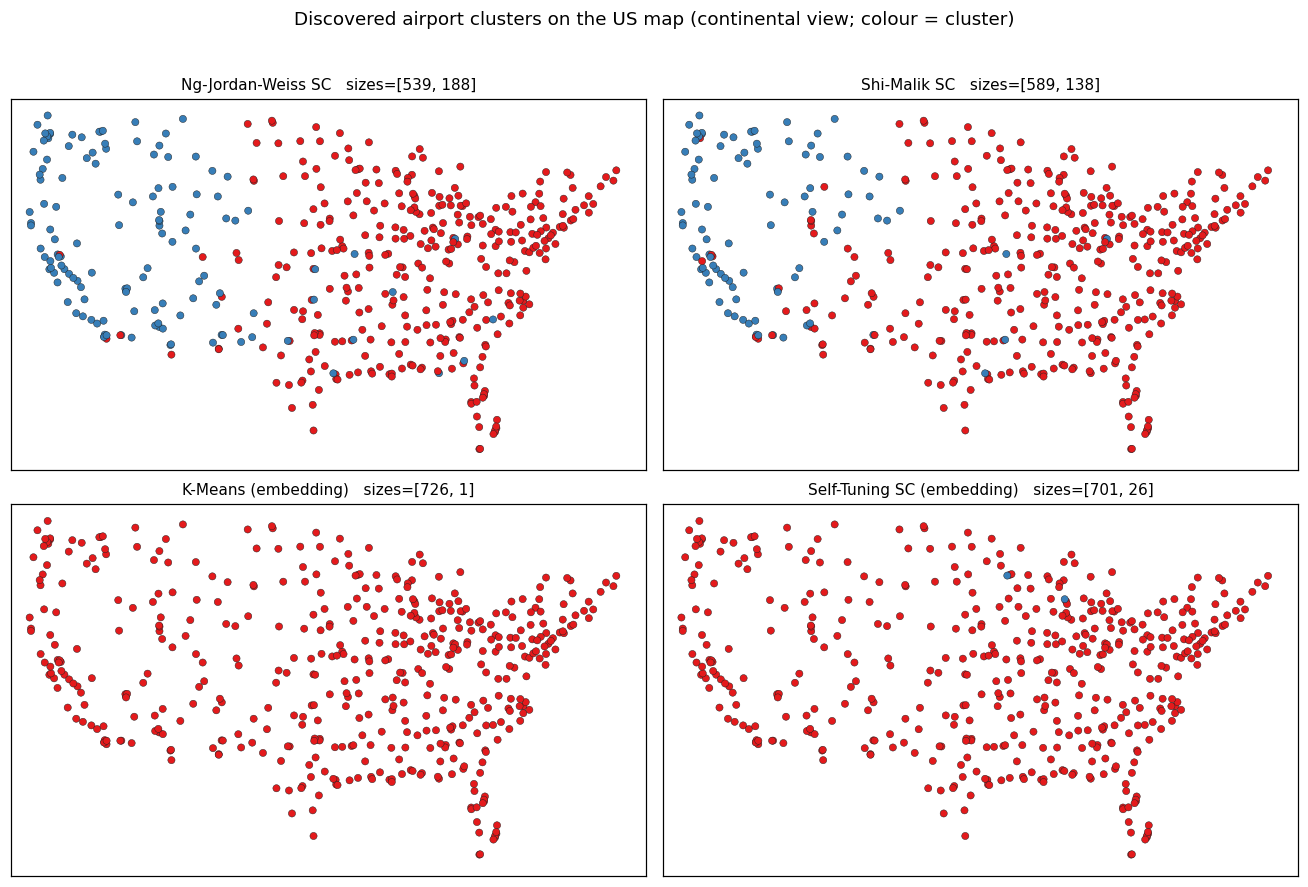

In [12]:
import numpy as np
from scripts.network_datasets import load_airport_coords

# high-contrast discrete palette (distinct hues; avoids tab10's low-contrast 2-value mapping)
PALETTE = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
           "#00ced1", "#f781bf", "#a65628"]
def cluster_colors(lab):
    return [PALETTE[int(c) % len(PALETTE)] for c in lab]

coords_df = load_airport_coords().drop_duplicates("airport").set_index("airport")
xy = {c: (float(coords_df.loc[c, "long"]), float(coords_df.loc[c, "lat"]))
      for c in coords_df.index}

have_idx = [i for i, c in enumerate(nodes) if c in xy]
xs = np.array([xy[nodes[i]][0] for i in have_idx])
ys = np.array([xy[nodes[i]][1] for i in have_idx])
print(f"Geographic coordinates available for {len(have_idx)}/{len(nodes)} airports "
      f"(joined by IATA code from the raw Kaggle data).")

geo_algos = ["Ng-Jordan-Weiss SC", "Shi-Malik SC",
             "K-Means (embedding)", "Self-Tuning SC (embedding)"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, algo in zip(axes.ravel(), geo_algos):
    lab = labels[algo][have_idx]
    sizes = sorted(np.bincount(labels[algo]).tolist(), reverse=True)
    ax.scatter(xs, ys, c=cluster_colors(lab), s=22, edgecolor="#222222", linewidth=0.3)
    ax.set_title(f"{algo}   sizes={sizes}", fontsize=10)
    ax.set_xlim(-126, -66); ax.set_ylim(23, 50); ax.set_aspect(1.3)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Discovered airport clusters on the US map "
             "(continental view; colour = cluster)", y=1.02)
plt.tight_layout(); plt.show()

The map makes the earlier tables tangible. **Ng-Jordan-Weiss** and
**Shi-Malik** paint a clean **West vs Central/East** partition — the West-coast /
Mountain-West airports (California, Pacific Northwest, Arizona, Utah, Nevada) form
one cluster and the rest of the country the other. **K-Means** is a single colour
with one lone point of the other (the $[726, 1]$ degenerate split — one isolated
airport), and **Self-Tuning** peels off only a small scattered handful. The
geography confirms which methods found real structure.

Force-directed layout of 727 airports and 22955 routes.


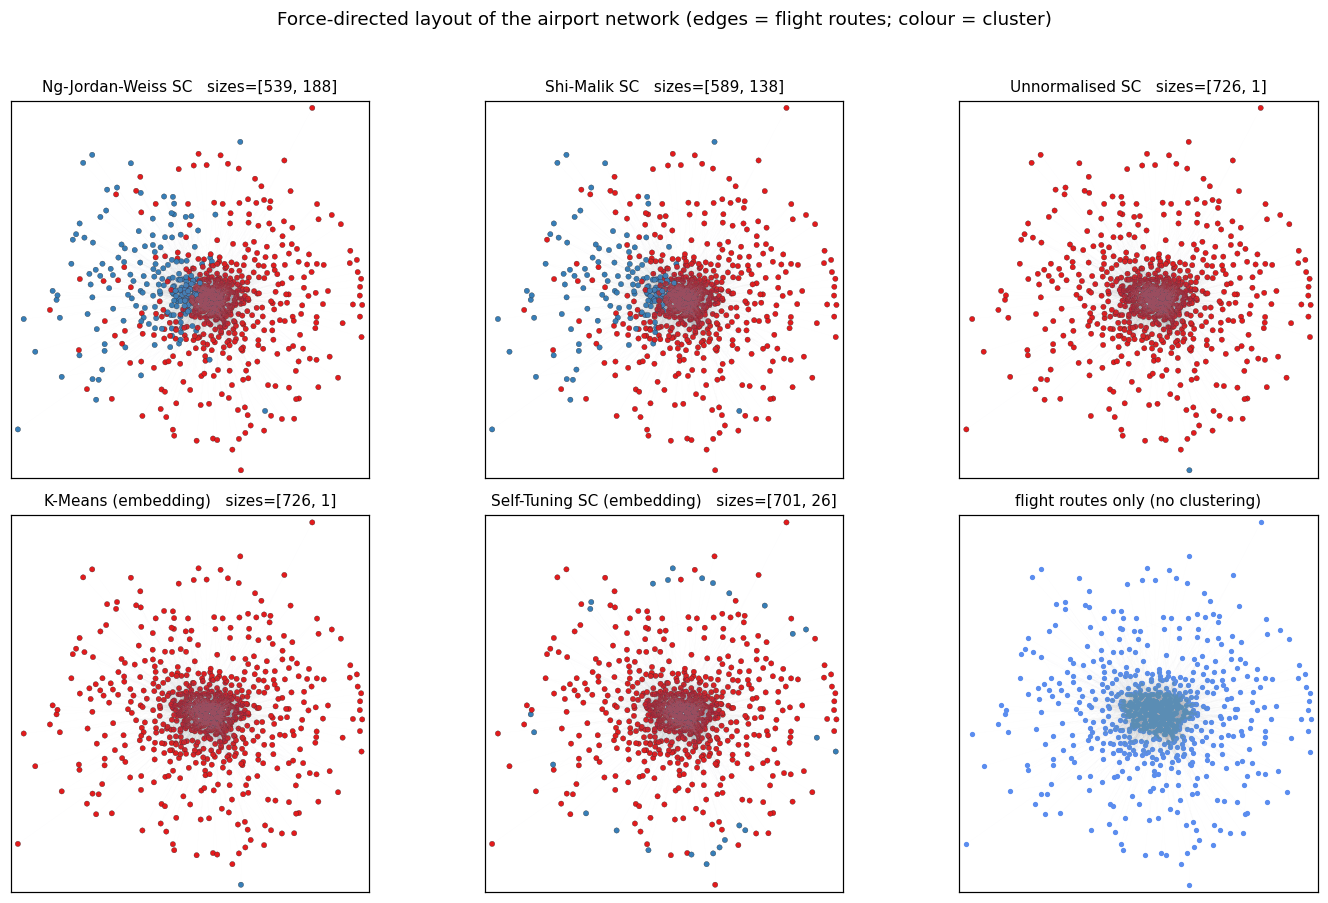

In [13]:
import networkx as nx
from matplotlib.collections import LineCollection

PALETTE = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
           "#00ced1", "#f781bf", "#a65628"]
cc = lambda lab: [PALETTE[int(c) % len(PALETTE)] for c in lab]

idx = {c: i for i, c in enumerate(nodes)}
pos = nx.spring_layout(G, seed=SEED, weight=None, iterations=60)
P = np.array([pos[nodes[i]] for i in range(len(nodes))])
segs = np.array([[P[idx[u]], P[idx[v]]] for u, v in G.edges()])
print(f"Force-directed layout of {len(nodes)} airports and {len(segs)} routes.")

panels = ["Ng-Jordan-Weiss SC", "Shi-Malik SC", "Unnormalised SC",
          "K-Means (embedding)", "Self-Tuning SC (embedding)", None]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 8))
for ax, algo in zip(axes.ravel(), panels):
    ax.add_collection(LineCollection(segs, colors="#9aa2b4", linewidths=0.15, alpha=0.04))
    if algo is None:
        ax.scatter(P[:, 0], P[:, 1], s=6, c="#5b8def")
        ax.set_title("flight routes only (no clustering)", fontsize=10)
    else:
        sizes = sorted(np.bincount(labels[algo]).tolist(), reverse=True)
        ax.scatter(P[:, 0], P[:, 1], s=12, c=cc(labels[algo]),
                   edgecolor="#222222", linewidth=0.2)
        ax.set_title(f"{algo}   sizes={sizes}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal"); ax.margins(0.02)
fig.suptitle("Force-directed layout of the airport network "
             "(edges = flight routes; colour = cluster)", y=1.02)
plt.tight_layout(); plt.show()

### What the visualisations show

The force-directed layout pulls the densely-interconnected hubs into the centre
and pushes sparsely-connected regional airports to the rim — the classic
hub-and-spoke signature. Against that backbone:

- **Ng-Jordan-Weiss** and **Shi-Malik** cut the network into two contiguous
  regions that coincide with the geographic West/East split on the map above — a
  genuine community structure.
- **Unnormalised SC**, **K-Means** and **Self-Tuning** collapse: on this hub-heavy
  graph the unnormalised methods isolate a single node and Self-Tuning finds only
  a small fringe, so almost every airport ends up the same colour.

Both views tell the same story as the internal metrics *once the fit-space
artefacts are stripped out*: degree-normalised spectral clustering
(Shi-Malik / Ng-Jordan-Weiss) is the only approach that recovers meaningful,
geographically-coherent structure on the airport network. This matches the
'nodes coloured by cluster, edges = flight routes' concept from the visualiser
mock-up, and the same pair of plots will drive the Dataset Explorer view for this
dataset.

## 10. Robustness check: removing the TVI outlier

Section 4b showed TVI is a degree-1 pendant leaf that the unnormalised methods
isolate into a $[726, 1]$ split; here we test whether TVI was the *sole* cause of
that degeneracy, or a symptom of a broader degree-imbalance problem that would
resurface with the next-most-extreme low-degree node. **This is an additional
exploration — the TVI-included results in Sections 1-9 are unchanged.**

In [14]:
import networkx as nx
from scripts.network_datasets import graph_to_adjacency

# 1-2. remove TVI and confirm the graph stays a single connected component
G_r = G.copy(); G_r.remove_node("TVI")
print(f"Removed TVI -> {G_r.number_of_nodes()} nodes, {G_r.number_of_edges()} edges, "
      f"connected={nx.is_connected(G_r)} ({nx.number_connected_components(G_r)} component)")

A_r, nodes_r = graph_to_adjacency(G_r)
Ad_r = A_r.toarray()
emb_r, tim_r = build_embeddings(A_r, n_components=10)
Xe_r = emb_r["unnorm"]

# 3. re-run k-selection (same two-step method, Silhouette disambiguation)
sel_r = select_spectral_k(Ad_r, Xe_r,
                          reference_fn=lambda kk: spectral_ng_jordan_weiss(Ad_r, kk),
                          ground_truth=None, top_n=3, k_min=2, k_max=8)
k_r = sel_r["best_k"]
print(f"k-selection: candidates={sel_r['candidates']} -> k={k_r}   "
      f"(original run selected k={k}) -> {'unchanged' if k_r == k else 'CHANGED'}")

# 3. re-run all five algorithms (same fixed seed)
algos_r = {
    "K-Means (embedding)":        lambda kk: kmeans_baseline(Xe_r, kk),
    "Unnormalised SC":            lambda kk: unnormalised_spectral(Ad_r, kk),
    "Shi-Malik SC":               lambda kk: spectral_shi_malik(Ad_r, kk),
    "Ng-Jordan-Weiss SC":         lambda kk: spectral_ng_jordan_weiss(Ad_r, kk),
    "Self-Tuning SC (embedding)": lambda kk: self_tuning_spectral(Xe_r, kk),
}
labels_r = {name: np.asarray(fn(k_r)) for name, fn in algos_r.items()}

# 4. direct comparison of cluster sizes vs the original (TVI-included) run
print("\nCluster sizes   original (TVI in)  ->  TVI removed:")
for name in labels_r:
    o = sorted(np.bincount(labels[name]).tolist(), reverse=True)
    n = sorted(np.bincount(labels_r[name]).tolist(), reverse=True)
    tag = "  <- still degenerate" if n[-1] == 1 and len(n) > 1 else ""
    print(f"  {name:28s} {str(o):14s} -> {str(n):14s}{tag}")

Removed TVI -> 726 nodes, 22954 edges, connected=True (1 component)


k-selection: candidates=[2, 6, 5] -> k=2   (original run selected k=2) -> unchanged

Cluster sizes   original (TVI in)  ->  TVI removed:
  K-Means (embedding)          [726, 1]       -> [725, 1]        <- still degenerate
  Unnormalised SC              [726, 1]       -> [725, 1]        <- still degenerate
  Shi-Malik SC                 [589, 138]     -> [588, 138]    
  Ng-Jordan-Weiss SC           [539, 188]     -> [538, 188]    
  Self-Tuning SC (embedding)   [701, 26]      -> [700, 26]     


In [15]:
# 3. multi-embedding evaluation + ranking consistency on the reduced graph
df_r, _tim = evaluate_multi_embedding(A_r, labels_r, n_components=10)
print("Silhouette (TVI removed):")
print(format_comparison_table(df_r, "silhouette").to_string(index=False))
print("\nDavies-Bouldin (TVI removed):")
print(format_comparison_table(df_r, "davies_bouldin").to_string(index=False))

# 4. did the embedding-ranking consistency improve?
print("\nRanking consistency (Spearman between embeddings)   original -> TVI removed:")
for metric in ("silhouette", "davies_bouldin"):
    c_o = ranking_consistency(df, metric)          # df = original table (Section 5)
    c_r = ranking_consistency(df_r, metric)
    print(f"  {metric:14s} unnorm~sym: {c_o['spearman']['unnorm~sym']:+.2f} -> "
          f"{c_r['spearman']['unnorm~sym']:+.2f}")

# 4. is there a 'next worst' outlier that now gets isolated?
mu_r = Xe_r.mean(0); dc_r = np.linalg.norm(Xe_r - mu_r, axis=1)
deg_r = dict(G_r.degree())
worst = nodes_r[int(np.argmax(dc_r))]
cnts = np.bincount(labels_r["K-Means (embedding)"])
km_singleton = [nodes_r[i] for i in np.where(labels_r["K-Means (embedding)"] == cnts.argmin())[0]]
print(f"\nMost extreme embedding outlier now: {worst} "
      f"(degree {deg_r[worst]}, dist-to-centroid {dc_r.max():.3f}, "
      f"vs TVI's 0.994); K-Means now isolates {km_singleton}.")
n_deg1 = sum(1 for _, d in G.degree() if d == 1)
print(f"The original network has {n_deg1} degree-1 airports ({100*n_deg1/len(nodes):.0f}% of nodes) "
      f"- a whole pool of leaves the unnormalised methods can isolate.")

Silhouette (TVI removed):
                 algorithm  silhouette_unnorm  silhouette_sym  silhouette_shortest_path
       K-Means (embedding)             0.9672         -0.7251                    0.3403
           Unnormalised SC             0.9672         -0.7251                    0.3403
              Shi-Malik SC             0.1586          0.4203                    0.1790
        Ng-Jordan-Weiss SC            -0.0332          0.3127                    0.1671
Self-Tuning SC (embedding)             0.8199         -0.6593                    0.0564

Davies-Bouldin (TVI removed):
                 algorithm  davies_bouldin_unnorm  davies_bouldin_sym  davies_bouldin_shortest_path
       K-Means (embedding)                 0.0187              6.3204                        0.5143
           Unnormalised SC                 0.0187              6.3204                        0.5143
              Shi-Malik SC                 4.0095              2.5150                        2.3206
        Ng-Jord

### Conclusion — a symptom, not the sole cause

Removing TVI does **not** repair the degeneracy. The unnormalised methods
immediately isolate the **next** degree-1 leaf, **DWH** (David Wayne Hooks, TX;
degree 1; embedding distance ~0.99, essentially identical to TVI's), producing the
same $[725, 1]$ split. *k* is still 2, the Silhouette scores barely move (K-Means
$0.967 \to 0.967$), and the embedding-ranking instability does **not** improve —
Silhouette unnorm~sym stays at $-0.8$ (Davies-Bouldin's even hardens to $-1.0$).
Meanwhile Shi-Malik and Ng-Jordan-Weiss are unchanged ($588/138$ and $538/188$ —
the original clusters minus one node), confirming they were already ignoring TVI
correctly.

The network contains **70 degree-1 airports (~10% of nodes)**; TVI was merely
first in the queue. So the unnormalised Laplacian's failure here is a **general
degree-imbalance problem, not a single-node fluke** — peel off the most extreme
leaf and the next inherits the localised eigenvector. For the dissertation this is
the stronger, more robust conclusion: the remedy is **degree normalisation**
(Shi-Malik / Ng-Jordan-Weiss), which is insensitive to the entire population of
leaves, rather than outlier removal, which would have to be repeated node after
node without ever fixing the underlying cause.

### Weighted modularity confirms it too

As a final independent check, weighted modularity on the reduced graph — compared
against the TVI-included values from Section 5.

In [16]:
Q_incl = {name: weighted_Q(lab, G, nodes) for name, lab in labels.items()}
Q_rem  = {name: weighted_Q(lab, G_r, nodes_r) for name, lab in labels_r.items()}
print(f"{'algorithm':28s}{'Q (TVI in)':>12s}{'Q (removed)':>13s}")
for name in labels:
    print(f'  {name:26s}{Q_incl[name]:>12.3f}{Q_rem[name]:>13.3f}')

algorithm                     Q (TVI in)  Q (removed)
  K-Means (embedding)             -0.000       -0.000
  Unnormalised SC                 -0.000       -0.000
  Shi-Malik SC                     0.136        0.136
  Ng-Jordan-Weiss SC               0.223        0.223
  Self-Tuning SC (embedding)      -0.000       -0.000


Weighted modularity is **unchanged** by removing TVI —
Ng-Jordan-Weiss stays at Q ≈ +0.223 and Shi-Malik at Q ≈ +0.136, while the three
degenerate methods stay at Q ≈ 0. This is the same conclusion Section 10 reached
from cluster sizes and embedding metrics: TVI was a symptom, not the cause, and
**degree normalisation — not outlier removal — is what yields real community
structure**.

## Cross-dataset modularity comparison (setup for Facebook)

Modularity of the two degree-normalised methods across the datasets analysed so
far. Airports uses **weighted** modularity (flight counts); Yeast uses
**unweighted** modularity (binary interactions), matching each graph's edge
semantics.

| Dataset | Shi-Malik SC | Ng-Jordan-Weiss SC |
|---|---:|---:|
| US Airports (weighted Q) | **+0.136** | **+0.223** |
| Yeast PPI (unweighted Q) | +0.024 | **+0.242** |
| Facebook (unweighted Q) | **+0.708** | **+0.708** |

**Ng-Jordan-Weiss is the strongest community-finder on both** (Q ≈ 0.22-0.24).
Shi-Malik is competitive on Airports but **collapses on the leaf-heavy Yeast
network** (Q ≈ 0.02 — the near-degenerate split of `03_yeast.ipynb`),
foreshadowing the degree-imbalance sensitivity that Facebook will test next.